**Programmer:** python_scripts (Abhijith Warrier)

**PYTHON SCRIPT TO DETECT FEATURE DRIFT BETWEEN TRAINING AND PRODUCTION DATA USING POPULATION STABILITY INDEX (PSI). ⚡️📊🔍**

In production ML systems, even if the model remains unchanged, the **input data** can evolve over time. Monitoring these changes is essential to ensure the model continues making reliable predictions.

One of the most widely used techniques for detecting **feature drift** is the **Population Stability Index (PSI)**. In this project, we’ll learn how to calculate PSI and use it to identify significant changes in feature distributions.

---

## **📦 Import Required Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---

## **🧩 Create Training & Production Data**

We’ll simulate a feature (e.g., customer income) from training and production environments.

In [2]:
np.random.seed(42)

training_feature = np.random.normal(
    loc=50000,
    scale=8000,
    size=5000
)

production_feature = np.random.normal(
    loc=56000,
    scale=9000,
    size=5000
)

---

## **📊 Visualize Feature Distribution**

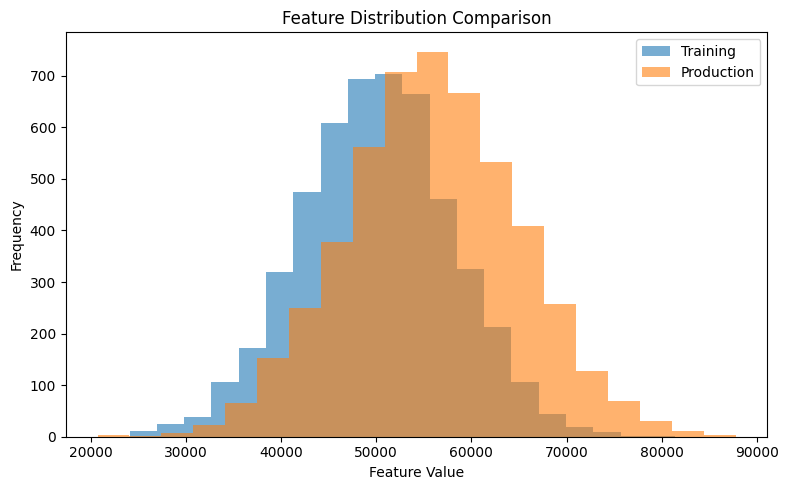

In [3]:
plt.figure(figsize=(8,5))

plt.hist(
    training_feature,
    bins=20,
    alpha=0.6,
    label="Training"
)

plt.hist(
    production_feature,
    bins=20,
    alpha=0.6,
    label="Production"
)

plt.title("Feature Distribution Comparison")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()
plt.show()

---

## **🏗️ Create Common Bins**

PSI compares both datasets using identical bins.

In [4]:
bins = np.linspace(
    min(training_feature.min(), production_feature.min()),
    max(training_feature.max(), production_feature.max()),
    11
)

---

## **📈 Calculate Bin Percentages**

In [5]:
train_counts, _ = np.histogram(
    training_feature,
    bins=bins
)

prod_counts, _ = np.histogram(
    production_feature,
    bins=bins
)

train_pct = train_counts / len(training_feature)
prod_pct = prod_counts / len(production_feature)

---

## **⚠️ Avoid Division by Zero**

In [6]:
epsilon = 1e-6

train_pct = np.where(
    train_pct == 0,
    epsilon,
    train_pct
)

prod_pct = np.where(
    prod_pct == 0,
    epsilon,
    prod_pct
)

---

## **🧮 Calculate PSI**

In [7]:
psi = np.sum(
    (
        train_pct -
        prod_pct
    )
    *
    np.log(
        train_pct /
        prod_pct
    )
)

print(
    f"Population Stability Index (PSI): {psi:.4f}"
)

Population Stability Index (PSI): 0.4862


---

## **🚦 Interpret PSI Score**

In [8]:
if psi < 0.10:
    print("✅ No significant drift detected.")

elif psi < 0.25:
    print("⚠️ Moderate feature drift detected.")

else:
    print("🚨 Significant feature drift detected.")

🚨 Significant feature drift detected.


---

## **📋 View Distribution Summary**

In [9]:
summary = pd.DataFrame({
    "Training %": train_pct.round(4),
    "Production %": prod_pct.round(4)
})

print(summary)

   Training %  Production %
0      0.0038        0.0012
1      0.0204        0.0058
2      0.0976        0.0434
3      0.2510        0.1254
4      0.3300        0.2536
5      0.2110        0.2826
6      0.0740        0.1880
7      0.0102        0.0770
8      0.0018        0.0200
9      0.0002        0.0030


---

## **🧠 Understanding PSI**

General interpretation:

| **PSI Score** | **Meaning** |
| --- | --- |
| < 0.10 | No significant drift |
| 0.10 – 0.25 | Moderate drift |
| > 0.25 | Significant drift |

---

## **🌍 Where PSI Is Used**

PSI is commonly used in:

- credit risk models
- fraud detection
- customer churn prediction
- recommendation systems
- production ML monitoring

It helps teams identify when incoming data no longer resembles the training data.

---

## **🧠 Key Takeaways**

1. Feature drift occurs when input feature distributions change over time.
2. PSI measures how different production data is from training data.
3. Both datasets must use identical bins for comparison.
4. Higher PSI values indicate greater feature drift.
5. PSI is one of the most widely used production ML monitoring metrics.

---

## **Conclusion**

Feature drift is often the earliest warning sign that a production ML model may require attention. By monitoring Population Stability Index (PSI), teams can detect distribution shifts before they significantly impact model performance, enabling timely retraining and more reliable machine learning systems.

This begins the **ML Systems Advanced** track in **Saturday ML Spark ⚡️**, focusing on advanced production monitoring techniques used by modern ML engineering teams.

---